In [7]:
import tensorflow as tf
import pathlib
import matplotlib.pyplot as plt
import os

"""
1) Buscar as máscaras - OK
2) Carregar e pré-processar as máscaras - OK
3) Criar pipeline para Aumento de Dados - OK
4) Configurar um dataset baseado nas máscaras - OK
5) Formular um treinamento - PENDENTE
6) Visualizar imagens - OK
"""


### 1. Configurar o caminho e criar lista de imagens ###
img_dir = '/media/renato/Data/PIBIC/FinalImage'
img_dir = pathlib.Path(img_dir)
mask_dir = '/media/renato/Data/PIBIC/FinalImagePPM_Mask'
mask_dir = pathlib.Path(mask_dir)

# Verificar se o diretório existe
if not os.path.exists(mask_dir):
    raise ValueError(f"Diretório não encontrado: {mask_dir}")

# Função para extrair o número do nome do arquivo
def get_file_number(filepath):
    return int(os.path.basename(filepath).replace('.png', ''))

# Verificar se os arquivos existem e converter PosixPath para strings 
mask_files = []
for path in mask_dir.glob('*.png'):
    if os.path.exists(path):
        mask_files.append(str(path))

# Ordenar a lista usando o número do arquivo como chave
mask_files = sorted(mask_files, key=get_file_number)

mask_count = len(mask_files)
print(f"Encontradas {mask_count} máscaras")

# Verificar se temos imagens
if mask_count == 0:
    raise ValueError(f"Nenhuma imagem PNG encontrada em: {mask_dir}")

# Mostrar alguns caminhos de exemplo
print("\nPrimeiros 5 caminhos de máscaras:")
for path in mask_files[:5]:
    print(path)

Encontradas 5036 máscaras

Primeiros 5 caminhos de máscaras:
/media/renato/Data/PIBIC/FinalImagePPM_Mask/000.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/001.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/002.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/003.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/004.png


In [8]:
### 2. Criar função para carregar e processar imagens ###
def load_and_preprocess_image(path):
    try:
        img_path = tf.convert_to_tensor(path, dtype=tf.string)
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.cast(img, tf.float32) / 255.0
        img = tf.image.resize(img, [224, 224], method='nearest')
        return img
    except Exception as e:
        print(f"Erro ao processar imagem {path}: {str(e)}")
        raise

In [9]:
### 3. Criar pipeline para Aumento de Dados ###
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2, interpolation='nearest'),
    tf.keras.layers.RandomZoom(0.2, interpolation='nearest'),
])

In [10]:
### 4. Criar e configurar o dataset ###
path_dataset = tf.data.Dataset.from_tensor_slices(mask_files)

# Verificar o primeiro item do dataset
print("\nVerificando primeiro item do dataset:")
for path in path_dataset.take(1):
    print(f"Caminho: {path.numpy().decode()}")
    print(f"Arquivo existe: {os.path.exists(path.numpy().decode())}")

# Carregar e preprocessar imagens
image_dataset = path_dataset.map(
    load_and_preprocess_image, 
    num_parallel_calls=tf.data.AUTOTUNE
)

# Configurar o dataset para treinamento
BATCH_SIZE = 32
BUFFER_SIZE = 1000

train_dataset = (image_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .map(
        lambda x: data_augmentation(x, training=True),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .prefetch(tf.data.AUTOTUNE)
)


Verificando primeiro item do dataset:
Caminho: /media/renato/Data/PIBIC/FinalImagePPM_Mask/000.png
Arquivo existe: True


2025-01-22 10:50:10.586687: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


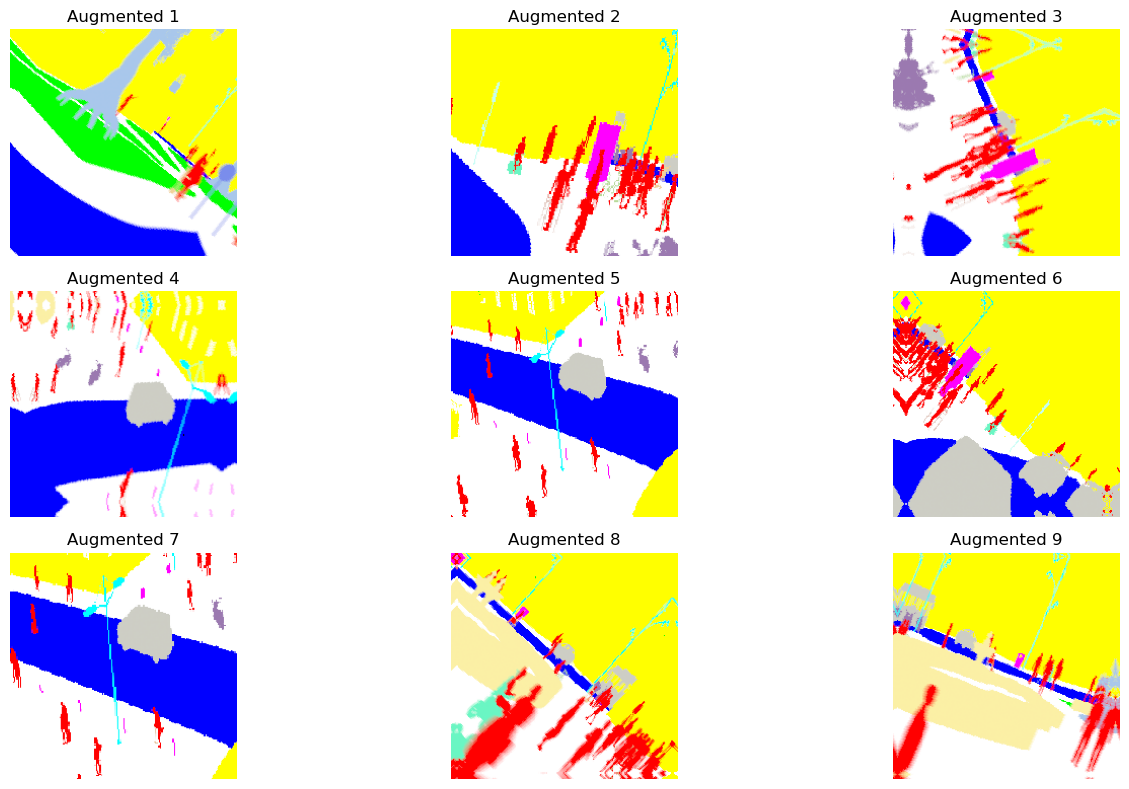

In [11]:
### 5. Tentar visualizar algumas imagens ###
try:
    plt.figure(figsize=(15, 8))
    for i, images in enumerate(train_dataset.take(1)):
        for j in range(min(9, BATCH_SIZE)):
            plt.subplot(3, 3, j+1)
            plt.imshow(images[j])
            plt.title(f'Augmented {j+1}')
            plt.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erro ao visualizar imagens: {str(e)}")

In [12]:
### 6. Informações úteis sobre o dataset ###
print(f"\nNúmero total de máscaras: {mask_count}")
print(f"Número de batches: {tf.data.experimental.cardinality(train_dataset)}")


Número total de imagens: 5036
Número de batches: 158


In [13]:
"""
Construção do modelo de treinamento
1) Carregar as imagens e as máscaras
2) Construir modelo simples
3) Construir previsão
4) Plotar pequena quantidade de amostras (3)
"""

'\nConstrução do modelo de treinamento\n1) Carregar as imagens e as máscaras\n2) Construir modelo simples\n3) Construir previsão\n4) Plotar pequena quantidade de amostras (3)\n'